# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [5]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


users.city: tiene 469 nulos (11.73%); recomiendo marcarlos como "Desconocida" para conservar los clientes sin atribuirles una ciudad sin evidencia.
users.churn_date: tiene 3,534 nulos (88.35%); recomiendo conservar la columna y confirmar si estos nulos representan clientes activos, ya que es relevante para analizar las bajas.
usage.date: tiene 50 nulos (0.125%); recomiendo mantener estos registros para análisis generales y excluirlos de análisis temporales, porque no podemos asignarles una fecha confiable.
usage.duration: tiene 22,076 nulos (55.19%); recomiendo revisar su distribución por type, conservar los nulos correspondientes a mensajes e investigar los de llamadas, porque la duración solo aplica a llamadas.
usage.length: tiene 17,896 nulos (44.74%); recomiendo revisar su distribución por type, conservar los nulos correspondientes a llamadas e investigar los de mensajes, porque la longitud solo aplica a mensajes.
plans y las demás columnas: no presentan nulos, por lo que no requieren tratamiento de valores faltantes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` contiene 4,000 valores no nulos, entre 10,000 y 13,999. Es un identificador de clientes; sus estadísticas no describen el consumo y debemos verificar su unicidad por separado. 
- La columna `age`presenta un mínimo de −999, una edad inválida que parece ser un sentinel. Este valor distorsiona la media (33.74 años) y la desviación estándar (123.23 años). La mediana es de 47 años y el máximo de 79. Recomiendo reemplazar −999 por un valor nulo y recalcular las estadísticas antes de decidir cómo tratar las edades faltantes.

In [15]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`no presentan nulos. id va de 1 a 40,000 y user_id de 10,000 a 13,999, un rango compatible con el dataset de clientes. Son identificadores; debemos verificar por separado la unicidad de id y que cada user_id exista en users.
- La columna duration tiene 17,924 valores registrados, una media de 5.20 y una mediana de 3.50. El máximo de 120 podría ser un valor atípico y requiere revisión. El mínimo de 0 podría representar una llamada sin conexión; debemos confirmar su significado antes de modificarlo.
-La columna length tiene 22,104 valores registrados, una media de 52.13 y una mediana de 50. El máximo de 1,490 podría ser un valor atípico o un error de registro. El mínimo de 0 requiere investigación, pues podría corresponder a un mensaje vacío.
En duration y length no se observan valores negativos. Recomiendo investigar los ceros y los extremos, y evaluar los nulos según el tipo de actividad antes de aplicar limpieza. 

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f"Valores únicos de {columna}:")
    print(users[columna].unique())
    print()


Valores únicos de city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores únicos de plan:
['Basico' 'Premium']



- La columna `city` contiene Medellín, Bogotá, Cali y las abreviaturas CDMX, GDL y MTY. También presenta el sentinel "?" y valores nulos (NaN). Recomiendo reemplazar "?" por un nulo
- La columna `plan` contiene únicamente "Basico" y "Premium", categorías que coinciden con el catálogo de plans. No se observan categorías inválidas ni valores nulos, por lo que no requiere correcciones en esta revisión. 

In [17]:
# explorar columna categórica de usage
usage['type'].unique()


array(['call', 'text'], dtype=object)

- La columna `type` contiene únicamente "call" y "text", correspondientes a llamadas y mensajes. No presenta valores nulos ni categorías inesperadas, por lo que no requiere correcciones. Estas categorías permitirán analizar duration en llamadas y length en mensajes.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

users.age: se identificó el valor inválido −999, que parece ser un sentinel. Recomiendo reemplazarlo por NaN y recalcular las estadísticas para evitar que distorsione el análisis de edad.
users.city: se encontró "?" como sentinel de ciudad desconocida. Recomiendo reemplazarlo por NaN y posteriormente marcar las ciudades faltantes como "Desconocida".
usage.duration y usage.length: se observaron ceros y valores extremos de 120 y 1,490, respectivamente. Recomiendo investigar su significado y evaluar los extremos con métodos de detección de outliers antes de modificarlos; no están confirmados como errores o sentinels.
users.plan y usage.type: las categorías coinciden con las esperadas, por lo que no requieren correcciones en esta revisión.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [20]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`,se observan 1,314 registros de 2022, 1,316 de 2023 y 1,330 de 2024. También aparecen 40 registros de 2026 (1% de los clientes), fuera del periodo del proyecto, cuyo límite es 2024. La conversión no generó fechas nulas. Recomiendo investigar las fechas de 2026 y, si no pueden corregirse con información confiable, reemplazarlas por NaT, conservando los clientes para los análisis que no dependan de su fecha de registro. 

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()


2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, los 39,950 registros con fecha corresponden a 2024, dentro del periodo del proyecto. Los 50 registros restantes (0.125%) tienen fechas faltantes (NaT), que aparecen como NaN al extraer el año. Recomiendo conservarlos para análisis generales de consumo y excluirlos de análisis temporales, ya que no conocemos cuándo ocurrieron

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
users.reg_date: se identificaron 40 fechas de 2026, posteriores al límite de 2024. Recomiendo investigar su origen y, si no pueden corregirse con evidencia, reemplazarlas por NaT, conservando los demás datos del cliente.
usage.date: no se observan años fuera de rango; todas las fechas disponibles corresponden a 2024. Los 50 registros sin fecha se excluirán de análisis temporales.
Justificación: no se imputarán fechas arbitrarias, porque podrían distorsionar las tendencias de consumo y la antigüedad de los clientes.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [24]:

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()
# Marcar fechas posteriores a 2024 como nulas
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda columna: columna.isna().mean())


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [26]:
# Verificación MAR en usage (Missing At Random) para length

usage.groupby('type')['length'].apply(lambda columna: columna.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

duration: no tiene nulos en llamadas, mientras que el 99.93% de los mensajes presenta duración nula. Se conservarán estos nulos porque la duración no aplica a mensajes.
length: no tiene nulos en mensajes, mientras que el 99.93% de las llamadas presenta longitud nula. Se conservarán estos nulos porque la longitud no aplica a llamadas.
Decisión: los nulos dependen de type y son principalmente estructurales. No se imputarán ni se eliminarán las filas, pues hacerlo podría distorsionar las estadísticas o descartar actividad válida.
Revisión adicional: los porcentajes no llegan al 100%; existen mensajes con duración registrada y llamadas con longitud registrada que conviene investigar como posibles inconsistencias.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)
usage["minutos_llamada"] = usage["duration"].where(
    usage["type"] == "call", 0
)

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "minutos_llamada": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [34]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "minutos_llamada": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [35]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

# Completar con cero el consumo de usuarios sin actividad registrada
columnas_consumo = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

user_profile[columnas_consumo] = (
    user_profile[columnas_consumo].fillna(0)
)

user_profile.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [42]:
# Resumen estadístico de las columnas numéricas
user_profile[[
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,22.831225
std,17.689919,2.359738,2.145139,16.592068
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.087500
50%,48.000000,5.000000,4.000000,19.735000
75%,63.000000,7.000000,6.000000,31.182500
max,79.000000,17.000000,15.000000,155.690000


In [43]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True).mul(100).round(2)


Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

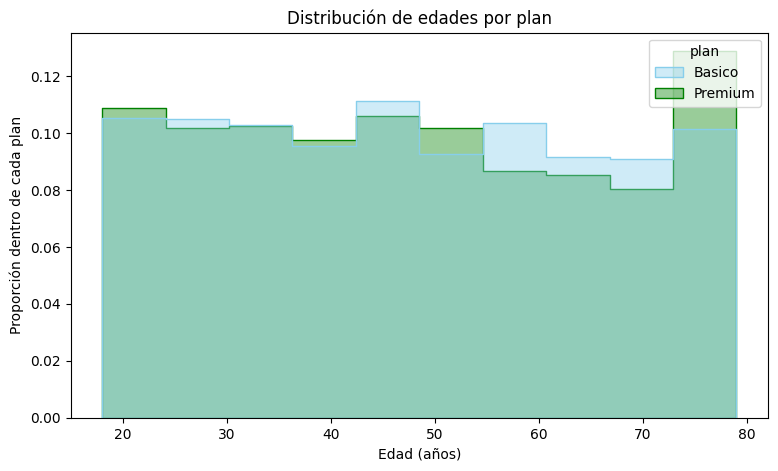

In [47]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(9, 5))

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    hue_order=['Basico', 'Premium'],
    palette=['skyblue', 'green'],
    bins=10,
    stat='probability',
    common_norm=False,
    element='step',
    alpha=0.4
)

plt.title('Distribución de edades por plan')
plt.xlabel('Edad (años)')
plt.ylabel('Proporción dentro de cada plan')
plt.show()

💡Insights: 
-  La distribución de edades es similar en los planes Básico y Premium, con proporciones relativamente uniformes entre los 18 y 79 años.
- Premium presenta una mayor proporción en el rango de mayor edad, mientras que Básico tiene una proporción ligeramente superior entre aproximadamente 55 y 73 años.
- Visualmente, no se observa una diferencia marcada de edad entre los usuarios de ambos planes.

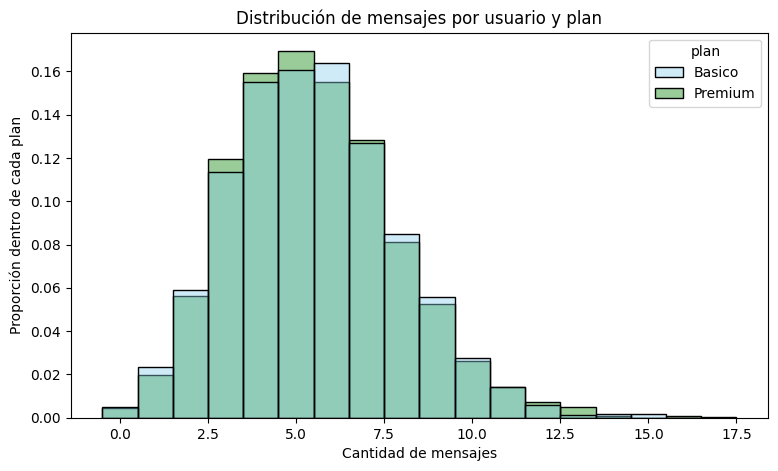

In [49]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(9, 5))

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    hue_order=['Basico', 'Premium'],
    palette=['skyblue', 'green'],
    discrete=True,
    stat='probability',
    common_norm=False,
    element='bars',
    alpha=0.4
)

plt.title('Distribución de mensajes por usuario y plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Proporción dentro de cada plan')
plt.show()


💡Insights: 
La distribución de la cantidad de mensajes es muy similar entre los usuarios de los planes Básico y Premium, ya que ambos histogramas prácticamente se superponen.
La mayor concentración de usuarios se encuentra aproximadamente entre 4 y 8 mensajes, con el punto de mayor frecuencia alrededor de 5–6 mensajes.
La distribución presenta asimetría positiva (sesgo hacia la derecha), ya que existen algunos usuarios con una cantidad de mensajes considerablemente mayor, llegando hasta aproximadamente 17 mensajes.
No se observa una diferencia importante en el comportamiento de mensajería entre ambos planes, por lo que, visualmente, pertenecer al plan Premium no parece estar asociado con una mayor cantidad de mensajes que pertenecer al plan Básico.

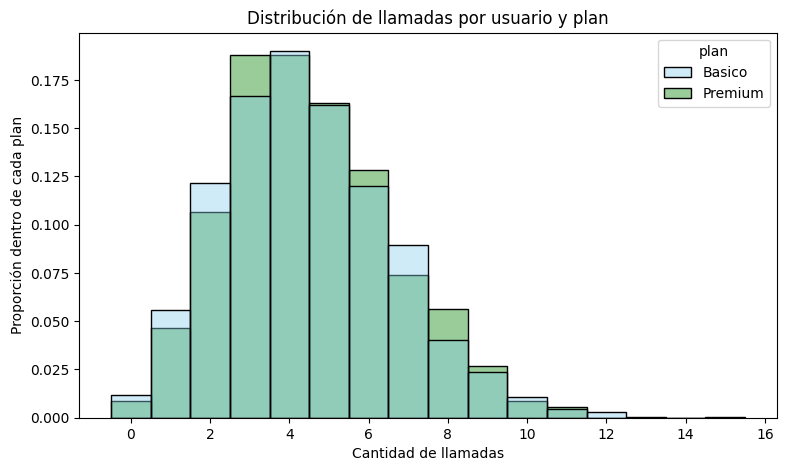

In [50]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(9, 5))

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    hue_order=['Basico', 'Premium'],
    palette=['skyblue', 'green'],
    discrete=True,
    stat='probability',
    common_norm=False,
    element='bars',
    alpha=0.4
)

plt.title('Distribución de llamadas por usuario y plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Proporción dentro de cada plan')
plt.show()


💡Insights: 
La distribución de llamadas es muy similar entre los planes Básico y Premium, con una superposición considerable entre ambos grupos.
La mayoría de los usuarios realiza aproximadamente entre 2 y 7 llamadas, y la mayor concentración se encuentra alrededor de 3–5 llamadas.
La distribución presenta sesgo hacia la derecha, ya que hay pocos usuarios que realizan un número elevado de llamadas, llegando a superar las 10 llamadas.
Visualmente, no se aprecia una diferencia importante en la cantidad de llamadas según el plan, por lo que ambos grupos muestran patrones de uso similares.

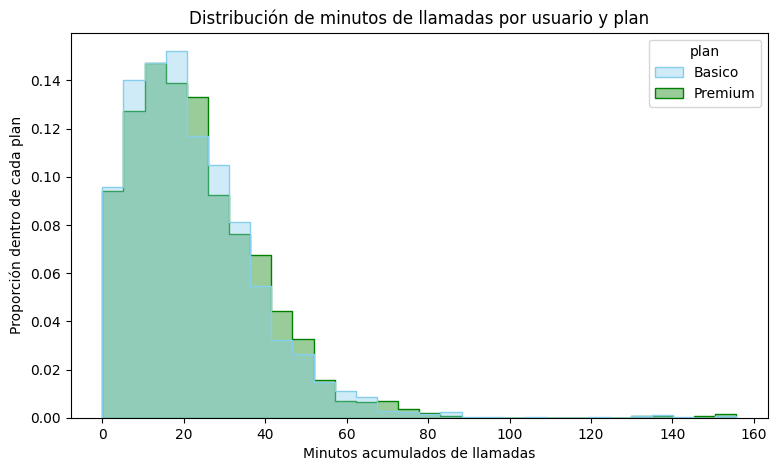

In [51]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(9, 5))

sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    hue_order=['Basico', 'Premium'],
    palette=['skyblue', 'green'],
    bins=30,
    stat='probability',
    common_norm=False,
    element='step',
    alpha=0.4
)

plt.title('Distribución de minutos de llamadas por usuario y plan')
plt.xlabel('Minutos acumulados de llamadas')
plt.ylabel('Proporción dentro de cada plan')
plt.show()


💡Insights: 
La distribución de los minutos acumulados de llamadas es muy similar entre los planes Básico y Premium, ya que ambas distribuciones se superponen ampliamente.
La mayor concentración de usuarios acumula aproximadamente entre 5 y 35 minutos de llamadas, con el pico alrededor de 15–20 minutos.
La distribución presenta un fuerte sesgo hacia la derecha, con pocos usuarios que acumulan tiempos de llamada muy elevados, incluso superiores a 100 minutos.
Se observan valores extremos cercanos a los 140–160 minutos, especialmente en el plan Premium.
En general, no se observa una diferencia clara en la duración de las llamadas entre ambos planes, por lo que visualmente el comportamiento de uso es similar.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

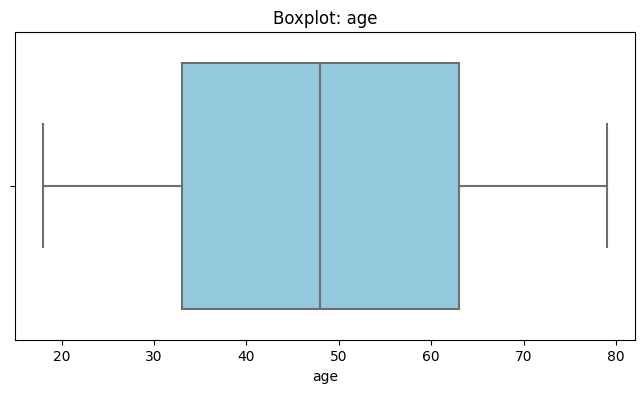

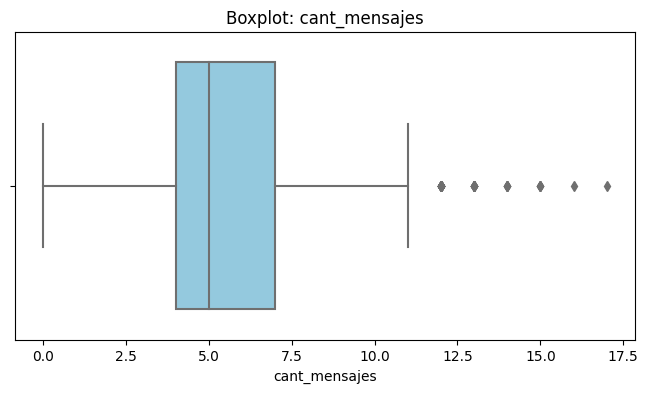

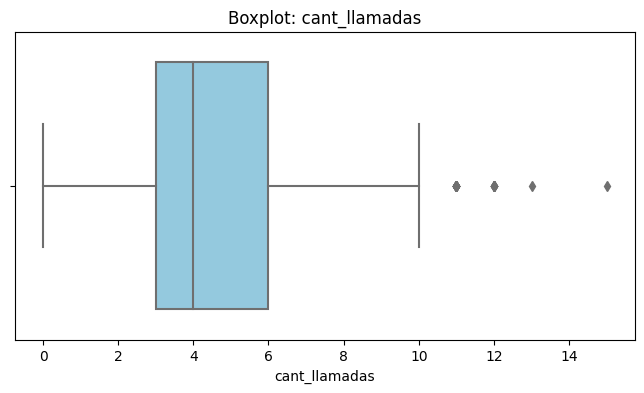

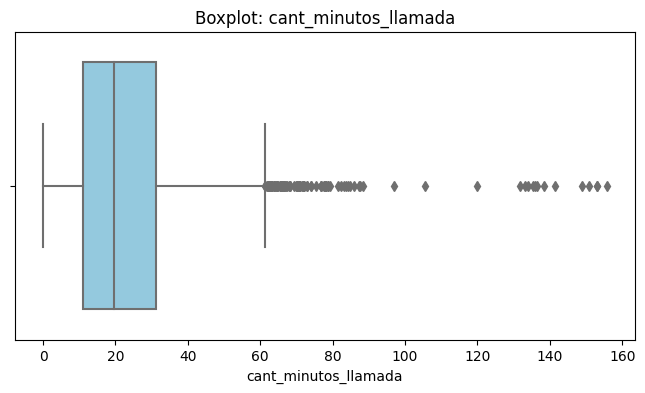

In [36]:
# Visualizar las variables mediante boxplots
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- **Edad:** No se observan outliers; las edades se encuentran dentro de los límites del boxplot.
- **Cantidad de mensajes:** Se observan outliers superiores, correspondientes a usuarios con 12 o más mensajes.
- **Cantidad de llamadas:** Se observan outliers superiores, correspondientes a usuarios con 11 o más llamadas.
- **Minutos de llamadas:** Se observan numerosos outliers superiores, con consumos acumulados por encima de aproximadamente 61.33 minutos.
- Estos valores requieren revisión, pero no demuestran por sí solos errores o fraude. Se conservarán para analizar a los usuarios de mayor consumo.

In [37]:
# Detectar outliers superiores mediante el método IQR
columnas_outliers = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_outliers:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    outliers = user_profile[
        user_profile[col] > limite_superior
    ]

    porcentaje = len(outliers) / len(user_profile) * 100

    print(f'\nVariable: {col}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Usuarios con outliers: {len(outliers)}')
    print(f'Porcentaje de usuarios: {porcentaje:.2f}%')




Variable: cant_mensajes
Límite superior: 11.50
Usuarios con outliers: 46
Porcentaje de usuarios: 1.15%

Variable: cant_llamadas
Límite superior: 10.50
Usuarios con outliers: 30
Porcentaje de usuarios: 0.75%

Variable: cant_minutos_llamada
Límite superior: 61.32
Usuarios con outliers: 96
Porcentaje de usuarios: 2.40%


In [38]:
# Revisar los máximos de las variables con outliers
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,22.831225
std,2.359738,2.145139,16.592068
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.087500
50%,5.000000,4.000000,19.735000
75%,7.000000,6.000000,31.182500
max,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes:** Se mantienen los 46 outliers (1.15%). El máximo de 17 mensajes es plausible y puede reflejar una mayor actividad del usuario, sin evidencia suficiente para considerarlo un error.

- **cant_llamadas:** Se mantienen los 30 outliers (0.75%). El máximo de 15 llamadas es plausible y permite identificar clientes que utilizan el servicio con mayor frecuencia.

- **cant_minutos_llamada:** Se mantienen los 96 outliers (2.40%), con un máximo de 155.69 minutos acumulados. Se recomienda revisar las llamadas que componen estos consumos para detectar posibles errores de registro.

Se conservarán los valores atípicos porque superar el límite IQR no implica que sean incorrectos. Estos usuarios son relevantes para la segmentación por nivel de consumo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [39]:
# Crear columna grupo_uso
def clasificar_uso(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(
    clasificar_uso, axis=1
)


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [41]:
# Crear columna grupo_edad
def clasificar_edad(row):
    edad = row['age']

    if edad < 30:
        return 'Joven'
    elif edad < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(
    clasificar_edad, axis=1
)


In [42]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

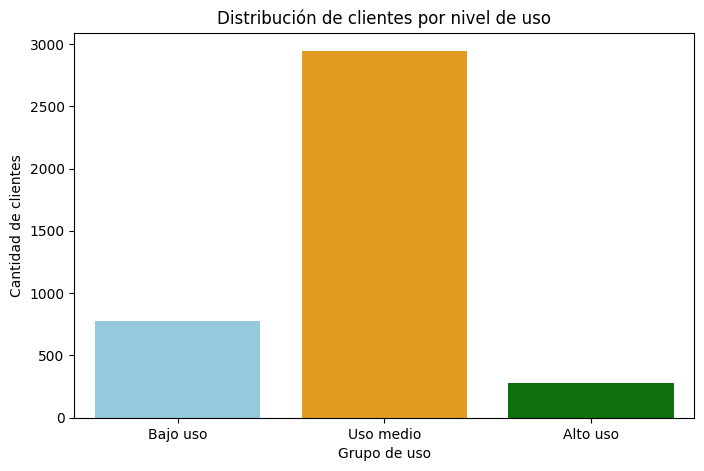

In [43]:
# Visualización de los segmentos por uso
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
    palette=['skyblue', 'orange', 'green']
)

plt.title('Distribución de clientes por nivel de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de clientes')
plt.show()

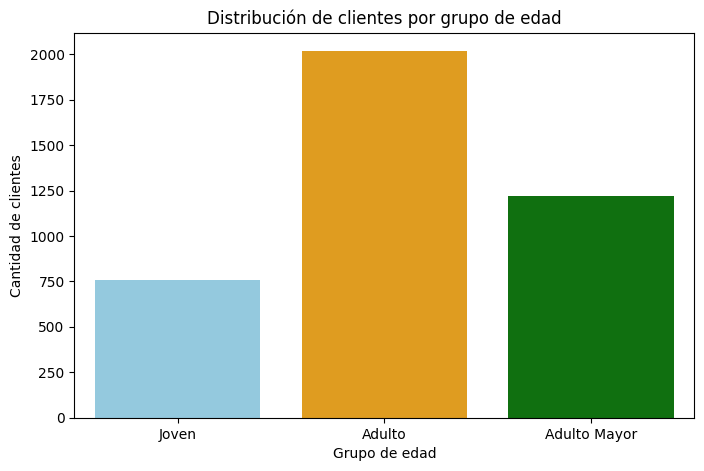

In [44]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    palette=['skyblue', 'orange', 'green']
)

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de clientes')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:

### Análisis ejecutivo de ConnectaTel

**1. Calidad de los datos**

Se analizaron 4,000 clientes y 40,000 registros de actividad. Se encontraron edades inválidas codificadas como -999, ciudades con el marcador “?” y 469 ciudades originalmente ausentes (11.73%). Las edades inválidas se reemplazaron por la mediana de las edades válidas y los marcadores de ciudad se transformaron en valores ausentes.

También se identificaron 40 fechas de registro posteriores a 2024 (1% de los clientes), que se marcaron como ausentes, y 50 actividades sin fecha (0.125% de los registros), que limitan el análisis temporal.

La columna churn_date tenía 3,534 valores ausentes (88.35%). Se conservaron porque podrían indicar clientes sin baja registrada. Los valores ausentes de duración y longitud se relacionan principalmente con el tipo de actividad: los mensajes no requieren duración y las llamadas no requieren longitud. No se imputaron estos campos.

**2. Segmentos y comportamiento de los clientes**

Se identificaron tres segmentos de uso: bajo, medio y alto, según la cantidad acumulada de llamadas y mensajes. Predomina el uso medio, seguido del bajo uso; el alto uso representa el grupo más pequeño.

Por edad, los adultos de 30 a 59 años son el grupo más numeroso, seguidos de los adultos mayores de 60 años o más y los jóvenes menores de 30. Esta distribución describe la cartera, pero por sí sola no demuestra diferencias de consumo entre edades.

El consumo promedio por cliente es de 5.52 mensajes, 4.48 llamadas y 22.83 minutos acumulados de llamadas. El plan Básico concentra el 64.88% de los clientes y Premium el 35.12%.

**3. Segmentos de interés comercial**

Los usuarios de uso medio constituyen una prioridad por su tamaño y ofrecen una oportunidad para evaluar mejoras que beneficien a una gran parte de la cartera. Los usuarios de alto uso merecen atención por sus posibles necesidades de mayor capacidad y oportunidades de retención.

Sin embargo, el mayor consumo no demuestra mayor rentabilidad. Para determinar qué segmentos son más valiosos se necesitan datos de ingresos, costos y permanencia. Tampoco corresponde recomendar Premium únicamente por pertenecer al grupo de alto uso.

**4. Valores atípicos**

El método IQR identificó 46 usuarios con cantidades atípicas de mensajes (1.15%), 30 con cantidades atípicas de llamadas (0.75%) y 96 con minutos acumulados atípicos (2.40%). Un mismo cliente puede aparecer en varias categorías.

Los máximos fueron 17 mensajes, 15 llamadas y 155.69 minutos acumulados. No se observaron outliers en edad después de la limpieza.

Se conservaron estos valores porque ser estadísticamente atípico no implica error o fraude. Conviene revisar las actividades que componen los consumos elevados, especialmente las llamadas de mayor duración.

**5. Recomendaciones comerciales**

- Evaluar opciones flexibles para los clientes de bajo uso, considerando precio, consumo mensual y necesidades de datos móviles.
- Priorizar el segmento de uso medio para probar mejoras de beneficios y medir su efecto en satisfacción y retención.
- Revisar individualmente a los usuarios de alto uso y ofrecer ajustes únicamente cuando su consumo mensual y sus preferencias lo justifiquen.
- Comparar el consumo por cliente entre planes y grupos de edad antes de diseñar campañas específicas.
- Analizar las bajas registradas por segmento para evaluar estrategias de retención.
- Mejorar las validaciones de edad, ciudad, fechas y campos correspondientes a cada tipo de actividad.

Los resultados describen el consumo acumulado en los registros disponibles. Antes de modificar los planes, es necesario confirmar la cobertura de esos registros y calcular el consumo mensual, ya que los beneficios contratados se renuevan cada mes. También hace falta información de uso de internet para evaluar integralmente la oferta.



### 7.2. Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Se identificaron edades inválidas (-999), ciudades con el marcador “?” y 469 ciudades originalmente ausentes (11.73%). Las edades inválidas se imputaron con la mediana de las edades válidas y “?” se reemplazó por un valor ausente.
- Se marcaron como ausentes 40 fechas de registro posteriores a 2024 (1%). Además, 50 registros de actividad carecen de fecha (0.125%), lo que limita su análisis temporal.
- Los valores ausentes de duración y longitud corresponden principalmente a campos que no aplican al tipo de actividad. Se conservaron sin imputarlos.
- Se detectaron outliers en mensajes (46 usuarios; 1.15%), llamadas (30; 0.75%) y minutos de llamadas (96; 2.40%). Se conservaron para revisión, porque no constituyen por sí solos evidencia de error o fraude.

🔍 **Segmentos por Edad**

- Los adultos de 30 a 59 años constituyen el grupo más numeroso, seguidos de los adultos mayores de 60 años o más.
- Los jóvenes menores de 30 años son el segmento más pequeño. Estas cantidades describen la cartera; todavía no permiten concluir qué grupo consume más servicios.

📊 **Segmentos por Nivel de Uso**

- Predomina el uso medio, seguido del bajo uso. El alto uso representa el segmento más pequeño, según las reglas de llamadas y mensajes acumulados.
- Las medianas por cliente son de 5 mensajes, 4 llamadas y 19.74 minutos acumulados. Los máximos alcanzan 17 mensajes, 15 llamadas y 155.69 minutos.
- El segmento de uso medio es relevante por su tamaño; el de alto uso merece atención por sus posibles necesidades diferenciadas. Para determinar su rentabilidad se requieren datos de ingresos, costos y permanencia.

➡️ **Esto sugiere que…**

ConnectaTel puede evaluar ofertas diferenciadas según la actividad de sus clientes. Sin embargo, antes de recomendar migraciones de plan, debe comparar el consumo mensual con los beneficios contratados y confirmar la cobertura de los registros disponibles.

💡 **Recomendaciones**

- Evaluar opciones flexibles para usuarios de bajo uso y mejoras de beneficios para el segmento de uso medio.
- Revisar los consumos extremos y las llamadas que los componen antes de aplicar cualquier corrección.
- Comparar el consumo por cliente entre planes y grupos de edad, y analizar las bajas por segmento para orientar acciones de retención.
- Incorporar el consumo de internet y reforzar las validaciones de edad, ciudad y fechas para mejorar las decisiones comerciales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`